In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from utils.preprocess import add_indicators, train_test_split
from utils.ticker_data import windowed_dfs, custom_windowed_dfs

hourly dsets go from 2023-07-14 14:30:00+00:00 to 2025-07-11 20:00:00+00:00

daily dsets go from 2000-01-04 to 2025-07-11

In [75]:
df = pd.read_csv("data/hourly/GC=F.csv")
if 'Date' in df:
    df['Date'] = pd.to_datetime(df.Date)
    df = df.set_index('Date')
elif 'Datetime' in df:
    df['Datetime'] = pd.to_datetime(df.Datetime)
    df = df.set_index('Datetime')

df.head()

,Open,High,Low,Close,Volume,logReturns
Datetime,,,,,,
2023-07-14 05:00:00+00:00,1964.300049,1965.300049,1961.900024,1963.000000,3779,-0.000713
2023-07-14 06:00:00+00:00,1963.000000,1964.500000,1959.800049,1960.699951,6273,-0.001172
2023-07-14 07:00:00+00:00,1960.699951,1961.699951,1958.400024,1961.199951,6551,0.000255
2023-07-14 08:00:00+00:00,1961.099976,1962.500000,1959.800049,1960.300049,5327,-0.000459
2023-07-14 09:00:00+00:00,1960.400024,1961.599976,1959.599976,1960.099976,2627,-0.000102


In [76]:
df_indicators = add_indicators(df)
df_indicators.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'logReturns', 'RSI5', 'RSI10',
       'SMA_5', 'SMA_10', 'EMA_10', 'MACD', 'BB_upper', 'BB_middle',
       'BB_lower'],
      dtype='object')

In [89]:
columns = ['Close', 'RSI10', 'MACD', 'EMA_10']
target = 'Close'
window_size = 30

scaler = StandardScaler()
for col in columns:
    df_indicators[col] = scaler.fit_transform(df_indicators[[col]])

# X, y = windowed_dfs(df_indicators, columns=columns, target=target, train_window=window_size)
# X, y = custom_windowed_dfs(df_indicators, {'Close':window_size}, target='Close')
X, y = custom_windowed_dfs(df_indicators, {'Close':window_size, 'RSI10':5, 'MACD':5, 'EMA_10':5, 'RSI10':5, 'MACD':5, 'EMA_10':5}, target='Close')

X

,close-30,close-29,close-28,close-27,close-26,close-25,close-24,close-23,close-22,close-21,...,macd-5,macd-4,macd-3,macd-2,macd-1,ema_10-5,ema_10-4,ema_10-3,ema_10-2,ema_10-1
0,-1.161202,-1.161202,-1.159894,-1.158804,-1.159240,-1.159676,-1.160330,-1.159676,-1.160112,-1.155971,...,0.955361,0.798208,0.661130,0.556090,0.434013,-1.122591,-1.120643,-1.118771,-1.116803,-1.115233
1,-1.161202,-1.159894,-1.158804,-1.159240,-1.159676,-1.160330,-1.159676,-1.160112,-1.155971,-1.152048,...,0.798208,0.661130,0.556090,0.434013,0.258414,-1.120643,-1.118771,-1.116803,-1.115233,-1.114543
2,-1.159894,-1.158804,-1.159240,-1.159676,-1.160330,-1.159676,-1.160112,-1.155971,-1.152048,-1.150958,...,0.661130,0.556090,0.434013,0.258414,0.144037,-1.118771,-1.116803,-1.115233,-1.114543,-1.113582
3,-1.158804,-1.159240,-1.159676,-1.160330,-1.159676,-1.160112,-1.155971,-1.152048,-1.150958,-1.149433,...,0.556090,0.434013,0.258414,0.144037,-0.015905,-1.116803,-1.115233,-1.114543,-1.113582,-1.113430
4,-1.159240,-1.159676,-1.160330,-1.159676,-1.160112,-1.155971,-1.152048,-1.150958,-1.149433,-1.151830,...,0.434013,0.258414,0.144037,-0.015905,-0.144302,-1.115233,-1.114543,-1.113582,-1.113430,-1.113345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11490,1.839708,1.837529,1.826631,1.834695,1.811157,1.814644,1.827939,1.815734,1.820529,1.829029,...,0.728734,1.046467,1.040027,1.314283,1.395577,1.870926,1.878286,1.882919,1.890914,1.897613
11491,1.837529,1.826631,1.834695,1.811157,1.814644,1.827939,1.815734,1.820529,1.829029,1.837093,...,1.046467,1.040027,1.314283,1.395577,1.124476,1.878286,1.882919,1.890914,1.897613,1.900675
11492,1.826631,1.834695,1.811157,1.814644,1.827939,1.815734,1.820529,1.829029,1.837093,1.834913,...,1.040027,1.314283,1.395577,1.124476,0.819904,1.882919,1.890914,1.897613,1.900675,1.902785
11493,1.834695,1.811157,1.814644,1.827939,1.815734,1.820529,1.829029,1.837093,1.834913,1.835785,...,1.314283,1.395577,1.124476,0.819904,0.646295,1.890914,1.897613,1.900675,1.902785,1.905700


In [90]:
X_train, y_train, X_test, y_test, test_dates = train_test_split(X, y, df.index, window_size=window_size)
(X_train.shape, y_train.shape, X_test.shape, y_test.shape, test_dates.shape)

((11150, 45), (11150,), (315, 45), (315,), (378,))

In [91]:
from sklearn.svm import SVR
model = SVR(kernel='rbf', C=1.0, epsilon=0.01)

In [92]:
model.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [93]:
y_pred = model.predict(X_test)

y_test = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1))

MAPE: 0.7100%


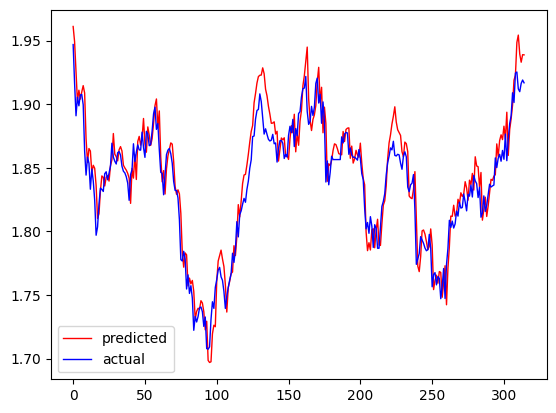

In [94]:
from sklearn.metrics import mean_absolute_percentage_error

print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)*100:.4f}%')
plt.plot(y_pred, c = 'r', lw = 1, label = 'predicted')
plt.plot(y_test, c='b', lw = 1, label = 'actual')

plt.legend()
plt.show()